In [1]:
import torch
import torch.nn as nn
import numpy as np
from pathlib import Path
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from src.data.tabular import split_data
from src.models.Autoencoder import Autoencoder
from src.hpo.autoencoder_hpo import create_study
from src.hpo.hidden_dims import build_hidden_dims_geo, build_hidden_dims_static
from src.training.train import train_final_model
from src.metrics.knn import find_best_neighbors, compute_knn_score


h:\Course contents FAU\semester 5\Thesis\final Project\LatentDimAnalysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

digits = load_digits()
X = digits.data
X = StandardScaler().fit_transform(X)  
y = digits.target
X_train, X_val, X_test, y_train, y_val, y_test, encoder = split_data(X, y)
X_train_tensor = torch.from_numpy(X_train).float()
X_val_tensor   = torch.from_numpy(X_val).float()
X_test_tensor  = torch.from_numpy(X_test).float()

y_train_tensor = torch.from_numpy(y_train)
y_val_tensor = torch.from_numpy(y_val)
X_train_val_tensor = torch.cat([X_train_tensor, X_val_tensor], dim=0)
y_train_val_tensor = torch.cat([y_train_tensor, y_val_tensor], dim=0)
X_train_val = X_train_val_tensor.detach().cpu().numpy()
y_train_val = y_train_val_tensor.detach().cpu().numpy()

print("X_train, X_val , X_test split shape",X_train.shape, X_val.shape, X_test.shape)
print("X_train_val split shape", X_train_val.shape)
n_features = X_train.shape[1]

X_train, X_val , X_test split shape (1078, 64) (360, 64) (359, 64)
X_train_val split shape (1438, 64)


In [3]:
import torch
from src.hpo.autoencoder_hpo import create_study

study = create_study(
    X_train_tensor,
    X_val_tensor,
    n_epochs=2,
    bottleneck_dim=2,
    n_trials=20,
    study_name="autoencoder_HPO_digits_analysis"
)

print(len(study.trials))
print(study.best_value)
print(study.best_params)

[I 2026-09-09 18:44:38,774] A new study created in memory with name: autoencoder_HPO_digits_analysis
Best trial: 2. Best value: 1.11749:  20%|██        | 4/20 [00:03<00:11,  1.42it/s]

[I 2026-09-09 18:44:42,360] Trial 0 finished with value: 1.1383075714111328 and parameters: {'lr': 0.0001329291894316216, 'depth': 3, 'activation': 'ReLU'}. Best is trial 0 with value: 1.1383075714111328.
[I 2026-09-09 18:44:42,410] Trial 1 finished with value: 1.1409893035888672 and parameters: {'lr': 1.493656855461762e-05, 'depth': 3, 'activation': 'Tanh'}. Best is trial 0 with value: 1.1383075714111328.
[I 2026-09-09 18:44:42,439] Trial 2 finished with value: 1.1174914836883545 and parameters: {'lr': 0.00314288089084011, 'depth': 1, 'activation': 'Tanh'}. Best is trial 2 with value: 1.1174914836883545.
[I 2026-09-09 18:44:42,469] Trial 3 finished with value: 1.1551433801651 and parameters: {'lr': 0.00019762189340280086, 'depth': 1, 'activation': 'ReLU'}. Best is trial 2 with value: 1.1174914836883545.
[I 2026-09-09 18:44:42,518] Trial 4 finished with value: 1.1368943452835083 and parameters: {'lr': 0.00023345864076016249, 'depth': 3, 'activation': 'GELU'}. Best is trial 2 with value

Best trial: 2. Best value: 1.11749:  50%|█████     | 10/20 [00:03<00:02,  4.70it/s]

[I 2026-09-09 18:44:42,543] Trial 5 pruned. 
[I 2026-09-09 18:44:42,575] Trial 6 pruned. 
[I 2026-09-09 18:44:42,620] Trial 7 pruned. 
[I 2026-09-09 18:44:42,650] Trial 8 pruned. 
[I 2026-09-09 18:44:42,696] Trial 9 finished with value: 1.135007381439209 and parameters: {'lr': 0.0006218704727769079, 'depth': 3, 'activation': 'Tanh'}. Best is trial 2 with value: 1.1174914836883545.


Best trial: 12. Best value: 1.10199:  70%|███████   | 14/20 [00:04<00:00,  6.78it/s]

[I 2026-09-09 18:44:42,734] Trial 10 pruned. 
[I 2026-09-09 18:44:42,777] Trial 11 finished with value: 1.117653250694275 and parameters: {'lr': 0.0024487287612782035, 'depth': 2, 'activation': 'Tanh'}. Best is trial 2 with value: 1.1174914836883545.
[I 2026-09-09 18:44:42,821] Trial 12 finished with value: 1.1019941568374634 and parameters: {'lr': 0.004214691459509996, 'depth': 2, 'activation': 'Tanh'}. Best is trial 12 with value: 1.1019941568374634.
[I 2026-09-09 18:44:42,853] Trial 13 pruned. 
[I 2026-09-09 18:44:42,901] Trial 14 finished with value: 1.131347417831421 and parameters: {'lr': 0.002482076244951993, 'depth': 2, 'activation': 'LeakyReLU'}. Best is trial 12 with value: 1.1019941568374634.


[I 2026-09-09 18:44:42,946] Trial 15 finished with value: 1.1149259805679321 and parameters: {'lr': 0.0027608868297492478, 'depth': 2, 'activation': 'Tanh'}. Best is trial 12 with value: 1.1019941568374634.
[I 2026-09-09 18:44:42,984] Trial 16 pruned. 
[I 2026-09-09 18:44:43,037] Trial 17 finished with value: 1.0995919704437256 and parameters: {'lr': 0.004482728234195076, 'depth': 2, 'activation': 'Tanh'}. Best is trial 17 with value: 1.0995919704437256.
[I 2026-09-09 18:44:43,080] Trial 18 finished with value: 1.1256688833236694 and parameters: {'lr': 0.004819025246600907, 'depth': 2, 'activation': 'LeakyReLU'}. Best is trial 17 with value: 1.0995919704437256.


Best trial: 17. Best value: 1.09959: 100%|██████████| 20/20 [00:04<00:00,  4.60it/s]

[I 2026-09-09 18:44:43,133] Trial 19 pruned. 
20
1.0995919704437256
{'lr': 0.004482728234195076, 'depth': 2, 'activation': 'Tanh'}


In [4]:
best_params = study.best_params
activations = {
    'ReLU': nn.ReLU,
    'LeakyReLU': nn.LeakyReLU,
    'GELU': nn.GELU,
    'Tanh': nn.Tanh
}

best_activation = activations.get(best_params.get('activation', 'ReLU'), nn.ReLU)
best_depth = best_params['depth']
best_lr = best_params['lr']
input_dim = X_train_val_tensor.shape[1]
bottleneck_range = [1, 2, 4, 8, 16, 32, 62]
epochs = 400

In [5]:
ae_errors = []
pca_errors = []
ae_knn = []
pca_knn = []

best_neighbors, best_val_score = find_best_neighbors(
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    y_val=y_val
)

print("Best neighbors:", best_neighbors)
print("Validation accuracy:", best_val_score)

for k in bottleneck_range:

    #final_hidden_dims = build_hidden_dims_geo(input_dim, k, best_depth)
    final_hidden_dims = build_hidden_dims_static(input_dim, depth=best_depth)

    pca = PCA(n_components=k)
    X_reduced_pca = pca.fit_transform(X_train_val)
    X_test_reduced_pca = pca.transform(X_test)
    X_recon_pca = pca.inverse_transform(X_reduced_pca)

    pca_knn_accuracy = compute_knn_score(
            X_train=X_reduced_pca,
            y_train=y_train_val,
            X_test=X_test_reduced_pca,
            y_test=y_test,
            n_neighbors=best_neighbors
    )

    pca_errors.append(np.mean((X_train_val - X_recon_pca) ** 2))
    pca_knn.append(pca_knn_accuracy)

    

    final_model = Autoencoder(
        n_features=input_dim,
        bottleneck_dim=k,
        non_linear=True,
        non_linear_function=best_activation,
        hidden_dims_list=final_hidden_dims
    )

    train_loss, test_loss, z_train_val, z_test  = train_final_model(
        final_model=final_model,
        X_train_val_tensor=X_train_val_tensor,
        X_test_tensor=X_test_tensor, 
        best_params=best_params, 
        epochs=400
    )
    z_train_val = z_train_val.cpu().numpy()
    z_test = z_test.cpu().numpy()
    ae_knn_accuracy = compute_knn_score(
        X_train=z_train_val,
        y_train=y_train_val,
        X_test=z_test,
        y_test=y_test,
        n_neighbors=best_neighbors
    )

    ae_knn.append(
        ae_knn_accuracy
    )
    ae_errors.append(train_loss)
    print(f"k={k:>3} PCA KNN={pca_knn_accuracy:.4f} AE KNN={ae_knn_accuracy:.4f} PCA={pca_errors[-1]:.4f}  Non Linear AE={ae_errors[-1]:.4f}")

Best neighbors: 5
Validation accuracy: 0.9583333333333334
k=  1 PCA KNN=0.3398 AE KNN=0.6490 PCA=0.8499  Non Linear AE=0.5365
k=  2 PCA KNN=0.5376 AE KNN=0.7827 PCA=0.7585  Non Linear AE=0.2981
k=  4 PCA KNN=0.8357 AE KNN=0.9136 PCA=0.6153  Non Linear AE=0.1779
k=  8 PCA KNN=0.9443 AE KNN=0.9443 PCA=0.4561  Non Linear AE=0.1131
k= 16 PCA KNN=0.9777 AE KNN=0.9721 PCA=0.2587  Non Linear AE=0.0868
k= 32 PCA KNN=0.9749 AE KNN=0.9777 PCA=0.0855  Non Linear AE=0.0562
k= 62 PCA KNN=0.9721 AE KNN=0.9777 PCA=0.0000  Non Linear AE=0.0489


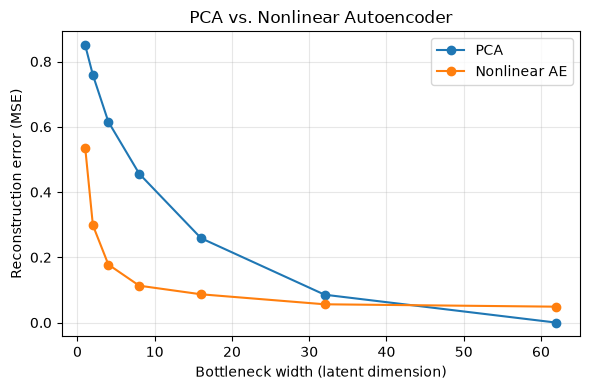

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(bottleneck_range, pca_errors, marker="o", label="PCA")
plt.plot(bottleneck_range, ae_errors, marker="o", label="Nonlinear AE")
plt.xlabel("Bottleneck width (latent dimension)")
plt.ylabel("Reconstruction error (MSE)")
plt.title("PCA vs. Nonlinear Autoencoder")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

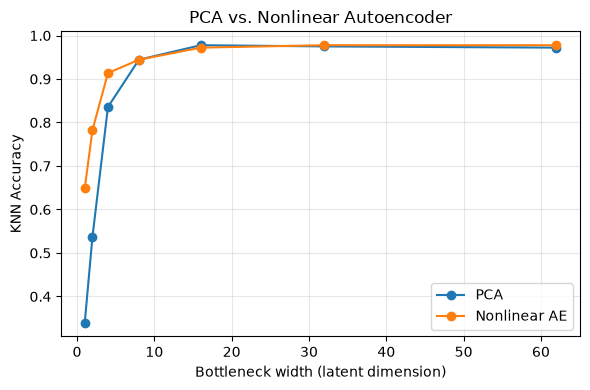

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(bottleneck_range, pca_knn, marker="o", label="PCA")
plt.plot(bottleneck_range, ae_knn, marker="o", label="Nonlinear AE")
plt.xlabel("Bottleneck width (latent dimension)")
plt.ylabel("KNN Accuracy")
plt.title("PCA vs. Nonlinear Autoencoder")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()